# 2 — SSL campaign: same preprocessing, different training story

**Research software — not for clinical use.**

This notebook is the SSL companion to `01_monai_nnunet_preprocessing.ipynb`.

Two pieces of work share the name “SSL” on the research branch. **Do not mix their metrics.**

| Campaign | What it is | What it is not |
|---|---|---|
| **Labeling** | The V1 nnU-Net teacher (`nnunet_fold0`, Dice **0.455**) drew **pseudo-labels** on unlabeled CTs. Planned 1000, finished **800**. | Not the 0.489 / 0.4965 scores |
| **Training** | New nnU-Net **5-fold** on the **163** locked train+val *labeled* cases. Compute limited us to **2 folds**. | Not a MONAI student. Test (29) never entered a fold. |

The website’s **SSL nnU-Net** button runs a **2-fold softmax ensemble** of those new folds. Locked-test ensemble Dice is **0.489**.

## 0. Setup

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nibabel as nib
import yaml

cwd = Path.cwd().resolve()
if (cwd / "config" / "preprocessing.yaml").is_file():
    ROOT = cwd
elif (cwd.parent / "config" / "preprocessing.yaml").is_file():
    ROOT = cwd.parent
else:
    raise FileNotFoundError("Run this notebook from the repo root or notebooks/")

src = ROOT / "src"
if str(src) not in sys.path:
    sys.path.insert(0, str(src))

DEMO = ROOT / "data" / "demo"
CT = DEMO / "01_all_classes" / "all_classes.nii.gz"
GT = DEMO / "ground_truth" / "01_all_classes" / "all_classes.nii.gz"
MANIFEST = DEMO / "MANIFEST.csv"
CFG = ROOT / "config" / "preprocessing.yaml"

LABELS = {0: "background", 1: "EDH", 2: "SDH", 3: "SAH", 4: "IPH", 5: "IVH"}
COLORS = {1: "#e74c3c", 2: "#f1c40f", 3: "#2ecc71", 4: "#3498db", 5: "#9b59b6"}

print("project:", ROOT)
print("demo CT:", CT.exists(), CT.name)
print("expert mask:", GT.exists())


project: C:\Users\1016f\OneDrive\Desktop\BrainHemorrhageAI-release
demo CT: True all_classes.nii.gz
expert mask: True


## 1. EDA reminder — we did not change the CT recipe

SSL uses the **same** clip `[-40, 120]` and **(HU − 40) / 80**.  
If that window changed, old and new models would not be comparable.

In [2]:
cfg = yaml.safe_load(CFG.read_text(encoding="utf-8"))
print("clip_min / clip_max:", cfg["clip_min"], cfg["clip_max"])
print("normalization:", cfg["normalization_method"], "mean", cfg["train_mean"], "std", cfg["train_std"])

from preprocessing.preprocess_volume import apply_intensity_clip, apply_normalization, resolve_clip_bounds

nii = nib.load(str(CT))
mask = nib.load(str(GT))
hu = nii.get_fdata().astype(np.float32)
gt = np.rint(mask.get_fdata()).astype(np.int64)
lo, hi = resolve_clip_bounds(cfg)
normed = apply_normalization(apply_intensity_clip(hu, lo, hi), cfg)

manifest = pd.read_csv(MANIFEST)
print()
print("Demo pack (what you can open without the full BHSD download)")
print(manifest.groupby("group")["filename"].count().to_string())


clip_min / clip_max: -40 120
normalization: zscore mean 40 std 80



Demo pack (what you can open without the full BHSD download)
group
EDH             2
IPH             2
IVH             2
SAH             2
SDH             2
all_classes     1
four_classes    6


### What the unlabeled campaign looked like (no unlabeled files on this branch)

We do **not** ship the 1980 unlabeled CTs here — they are large and not needed to use the app.

| Fact | Number |
|---|---|
| Unlabeled pool | 1980 (562 any-bleed / 1418 no-bleed on teacher inference) |
| Teacher | V1 `nnunet_fold0` |
| Planned LabelRun | 1000 cases |
| Finished | **800** (one 12-hour GPU session ≈ 1000 was too tight at ~52 s/case) |

Those 800 masks are **pseudo-labels**. They are not the locked-test score.

## 2. Why a new 5-fold at all?

The labeling campaign used the **old** V1 teacher. The **training** campaign trained **new** nnU-Net folds on the official 163 labeled development cases (train+val), with the 29-case test **held out**.

A 5-fold would have given a more stable estimate. We stopped at **fold 0 and fold 1** because of Kaggle’s 12-hour cap (several resume sessions per fold).

,run,kind,Dice,IoU,vol_err_mL
0,V1 nnU-Net fold0 (teacher),single fold,0.4550,0.313,14.3
1,New fold0 ~epoch 510,single fold,0.4800,NaN,NaN
2,New fold1 epoch 511 (best fold),single fold,0.4965,NaN,NaN
3,New fold1 epoch 679 (do not serve),single fold,0.4420,NaN,NaN
4,SSL 2-fold ensemble (what the UI runs),ensemble,0.4890,0.343,18.5
5,MONAI (for scale),single model,0.2570,0.163,19.5


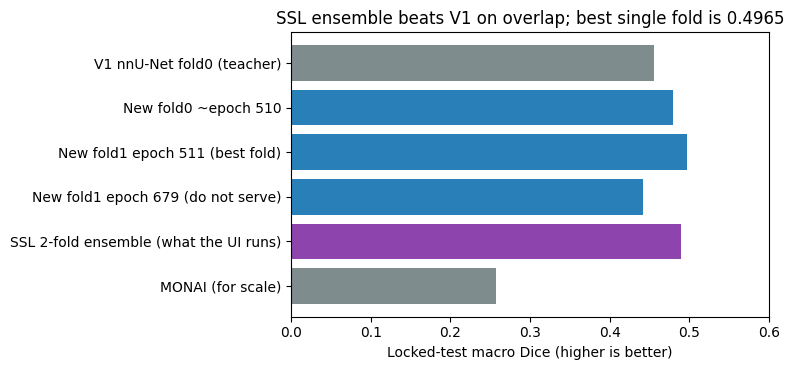

In [3]:
# Locked-test scores we actually measured (n=29, classes 1-5).
# These are research results, not computed in this cell.
scores = pd.DataFrame([
    {"run": "V1 nnU-Net fold0 (teacher)", "kind": "single fold", "Dice": 0.455, "IoU": 0.313, "vol_err_mL": 14.3},
    {"run": "New fold0 ~epoch 510", "kind": "single fold", "Dice": 0.480, "IoU": None, "vol_err_mL": None},
    {"run": "New fold1 epoch 511 (best fold)", "kind": "single fold", "Dice": 0.4965, "IoU": None, "vol_err_mL": None},
    {"run": "New fold1 epoch 679 (do not serve)", "kind": "single fold", "Dice": 0.442, "IoU": None, "vol_err_mL": None},
    {"run": "SSL 2-fold ensemble (what the UI runs)", "kind": "ensemble", "Dice": 0.489, "IoU": 0.343, "vol_err_mL": 18.5},
    {"run": "MONAI (for scale)", "kind": "single model", "Dice": 0.257, "IoU": 0.163, "vol_err_mL": 19.5},
])
display(scores)

fig, ax = plt.subplots(figsize=(8, 3.8))
plot = scores.dropna(subset=["Dice"]).copy()
colors = ["#7f8c8d" if "MONAI" in r or "V1" in r else ("#8e44ad" if "ensemble" in r else "#2980b9") for r in plot["run"]]
ax.barh(plot["run"][::-1], plot["Dice"][::-1], color=colors[::-1])
ax.set_xlabel("Locked-test macro Dice (higher is better)")
ax.set_xlim(0, 0.6)
ax.set_title("SSL ensemble beats V1 on overlap; best single fold is 0.4965")
plt.tight_layout()
plt.show()


**How to say this to a non-technical audience**

- The **app** averages two new folds. That average scores **0.489**.
- One of those folds alone scored **0.4965**. We still ship the average, because that is what “2-fold ensemble” means.
- The ensemble **draws better** than V1 nnU-Net (0.489 vs 0.455) but is **a bit worse on millilitres** (18.5 vs 14.3 mL). Overlap and volume are different questions.

## 3. Same picture, SSL context

The CT below is still `all_classes` after the **locked** window. SSL did not invent a new window.

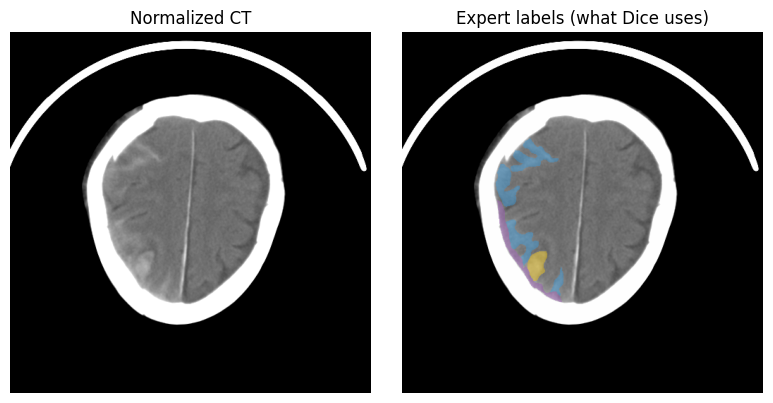

slice 24


In [4]:
z = int(np.argmax((gt > 0).sum(axis=(0, 1))))
sl = normed[:, :, z]
sl = (sl - sl.min()) / (sl.max() - sl.min() + 1e-6)
rgb = np.stack([sl, sl, sl], axis=-1)
color_layer = np.zeros_like(rgb)
for lab, col in COLORS.items():
    hexcol = col.lstrip("#")
    rgb_c = np.array([int(hexcol[i:i+2], 16) / 255 for i in (0, 2, 4)])
    color_layer[gt[:, :, z] == lab] = rgb_c
mix = np.where(gt[:, :, z][..., None] > 0, 0.55 * rgb + 0.45 * color_layer, rgb)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(np.rot90(sl), cmap="gray", origin="lower")
axes[0].set_title("Normalized CT")
axes[1].imshow(np.rot90(mix), origin="lower")
axes[1].set_title("Expert labels (what Dice uses)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print("slice", z)


## 4. Inference — brief, for a non-technical reader

**What the SSL button does.** It loads **two** weight files (fold 0 and fold 1) and averages their softmax probabilities. That is slower than one nnU-Net (~2×) and needs ~2 GB Docker shared memory (already set in `docker-compose.yml`).

**What you should click in a talk**

1. MONAI first — so the room sees *something* in 20 seconds.
2. SSL nnU-Net if you have several minutes — “this is the campaign model, Dice 0.489.”

**What you should not claim**

- That 0.4965 is the number the website produces (that was one fold).
- That SSL “uses the unlabeled 800” as the served weights — those 800 were a **labeling** campaign. The served model was trained on the **163 labeled** cases.
- That a better Dice always means a better millilitre count.

Run the app with Docker (`README.md`). This notebook does not start the predictor.

## 5. One-sentence summary

SSL kept the **same CT window** as MONAI / V1 nnU-Net; the new work is **two extra 3D folds** plus an optional unlabeled labeling run; the website serves the **2-fold ensemble (Dice 0.489)**, which beats V1 on overlap and loses on volume error.